In [1]:
# This cell contains all the necessary imports for the entire project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

### 1. Load and Explore the Data

In [2]:
# Load the dataset
orders = pd.read_csv("dataset/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("dataset/raw/olist_order_items_dataset.csv")
customers = pd.read_csv("dataset/raw/olist_customers_dataset.csv")
reviews = pd.read_csv("dataset/raw/olist_order_reviews_dataset.csv")

In [3]:
# Create a summary table per order
order_items_summary = order_items.groupby("order_id").agg({
    "price": "sum",              
    "freight_value": "mean",
}).reset_index()

# Merge orders with the summarized order_items table
df = pd.merge(orders, order_items_summary, on="order_id", how="left")

In [4]:
# Merge customer city and state info to the orders table
df = pd.merge(df,customers[["customer_id","customer_city","customer_state"]],on="customer_id" ,how = "left")

In [5]:
# Add customer review score for each order
df = pd.merge(df, reviews[["order_id", "review_score"]], on="order_id", how="left")

In [6]:
print(df.shape)
df.head()

(99992, 13)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,8.72,sao paulo,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,22.76,barreiras,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,19.22,vianopolis,GO,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,27.20,sao goncalo do amarante,RN,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,8.72,santo andre,SP,5.0


In [18]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'price', 'freight_value', 'customer_city', 'customer_state',
       'review_score', 'delivered_late', 'delivery_time_days',
       'carrier_delay_days', 'delivery_diff_estimated_days',
       'price_freight_ratio'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99992 non-null  object 
 1   customer_id                    99992 non-null  object 
 2   order_status                   99992 non-null  object 
 3   order_purchase_timestamp       99992 non-null  object 
 4   order_approved_at              99831 non-null  object 
 5   order_delivered_carrier_date   98199 non-null  object 
 6   order_delivered_customer_date  97005 non-null  object 
 7   order_estimated_delivery_date  99992 non-null  object 
 8   price                          99214 non-null  float64
 9   freight_value                  99214 non-null  float64
 10  customer_city                  99992 non-null  object 
 11  customer_state                 99992 non-null  object 
 12  review_score                   99224 non-null 

In [8]:
# missing values
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1793
order_delivered_customer_date    2987
order_estimated_delivery_date       0
price                             778
freight_value                     778
customer_city                       0
customer_state                      0
review_score                      768
dtype: int64

In [9]:
# List of date columns to convert
date_columns =[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
# Converting columns to datetime
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [10]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoric_cols = df.select_dtypes(include=['object']).columns.tolist()

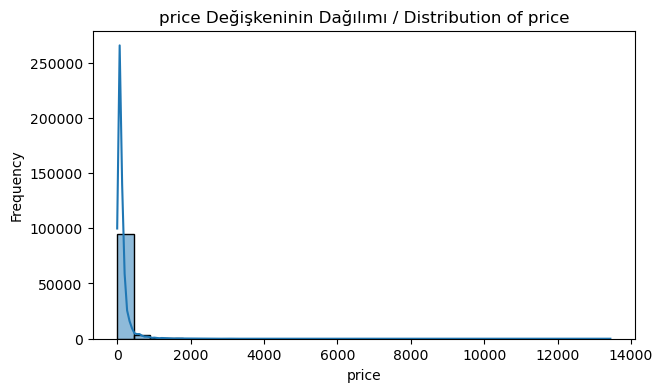

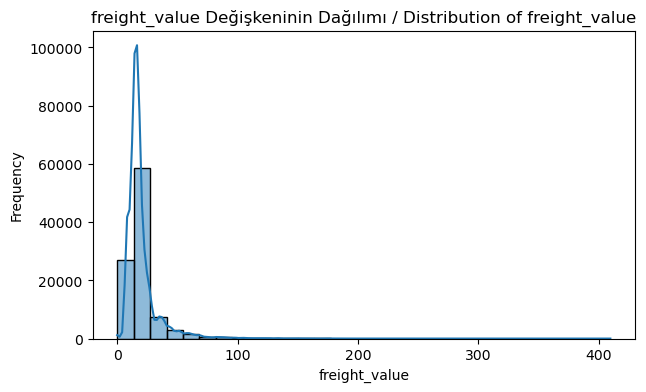

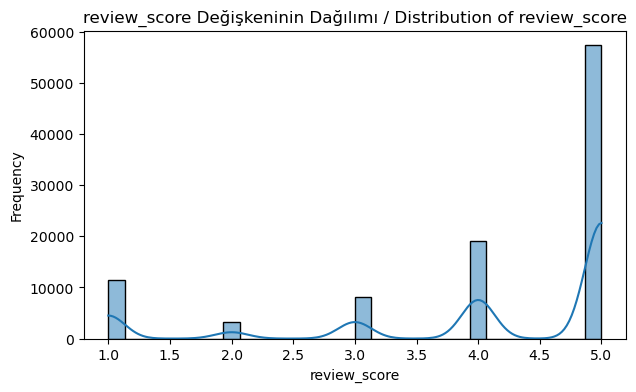

In [11]:
# Histogram for numeric columns
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"{col} Değişkeninin Dağılımı / Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### 2. Train-Test Split

In [12]:
# Create target variable
df["delivered_late"] = (df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]).astype(int)
print(df[["order_estimated_delivery_date", "order_delivered_customer_date", "delivered_late"]].head())
print("Missing values in target:", df["delivered_late"].isna().sum())

  order_estimated_delivery_date order_delivered_customer_date  delivered_late
0                    2017-10-18           2017-10-10 21:25:13               0
1                    2018-08-13           2018-08-07 15:27:45               0
2                    2018-09-04           2018-08-17 18:06:29               0
3                    2017-12-15           2017-12-02 00:28:42               0
4                    2018-02-26           2018-02-16 18:17:02               0
Missing values in target: 0


In [13]:
# Separate features and target
X = df.drop(["delivered_late", "order_id", "customer_id", 
             "order_delivered_customer_date", "order_estimated_delivery_date"], axis=1,errors='ignore')
y = df["delivered_late"]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,     
    stratify=y           
)
X_train.to_csv('dataset/processed/X_train.csv', index=False)
X_test.to_csv('dataset/processed/X_test.csv', index=False)
y_train.to_csv('dataset/processed/y_train.csv', index=False)
y_test.to_csv('dataset/processed/y_test.csv', index=False)

# Check shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (79993, 9)
X_test : (19999, 9)


In [14]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1793
order_delivered_customer_date    2987
order_estimated_delivery_date       0
price                             778
freight_value                     778
customer_city                       0
customer_state                      0
review_score                      768
delivered_late                      0
dtype: int64

### 3. Feature Engineering

In [15]:
# Days between order approval and actual delivery to customer
df["delivery_time_days"] = (df["order_delivered_customer_date"] - df["order_approved_at"]).dt.days

# Days between approval and carrier pickup
df["carrier_delay_days"] = (df["order_delivered_carrier_date"] - df["order_approved_at"]).dt.days

# Days early/late relative to estimated date
df["delivery_diff_estimated_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

# The relation between price and freight 
df["price_freight_ratio"] = df["price"] / df["freight_value"]
df["price_freight_ratio"] = df["price_freight_ratio"].replace([np.inf, -np.inf], np.nan)



In [16]:
df.to_csv('dataset/processed/eda_df.csv', index=False)

In [17]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1793
order_delivered_customer_date    2987
order_estimated_delivery_date       0
price                             778
freight_value                     778
customer_city                       0
customer_state                      0
review_score                      768
delivered_late                      0
delivery_time_days               3001
carrier_delay_days               1807
delivery_diff_estimated_days     2987
price_freight_ratio              1116
dtype: int64